# 02 — Ablation các tham số Pruning / Regularization của Random Forest

**Mục tiêu**: trả lời 2 câu hỏi học thuật trên dataset OULAD đã được EDA + preprocess ở notebook 01:

1. `ccp_alpha`, `min_impurity_decrease`, `max_depth` ảnh hưởng độ chính xác như thế nào?
2. Khi siết các tham số này (regularization mạnh hơn) thì **cái giá phải trả** là gì?

**Phương pháp đánh giá**: Stratified 5-fold Cross-Validation trên toàn bộ 32,593 mẫu, đo các metrics:

| Metric | Ý nghĩa |
|--------|---------|
| Test Accuracy / Train Accuracy | Đường cong học (learning curve). Khoảng cách giữa hai = mức overfit |
| F1 / Precision / Recall (positive = Pass) | Ngoài accuracy, vì data hơi mất cân bằng (47% Pass) |
| Training time (giây) | Trade-off chi phí tính toán |
| Tổng số node trong rừng | Trade-off độ phức tạp / kích thước model |
| Overfitting gap (Train − Test) | Trade-off bias-variance |

Output cuối: 4 file PNG ở `reports/figures/` + best params được chốt cho `train.py`.

## Section 1 — Setup & load data

In [1]:
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['savefig.bbox'] = 'tight'

# Paths — notebook chạy từ thư mục notebooks/
ROOT = Path('..').resolve()
DATA_PROCESSED = ROOT / 'data' / 'processed'
FIG_DIR = ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

X = pd.read_parquet(DATA_PROCESSED / 'X.parquet')
y = pd.read_parquet(DATA_PROCESSED / 'y.parquet')['target']

with open(DATA_PROCESSED / 'feature_metadata.json', 'r', encoding='utf-8') as f:
    META = json.load(f)

print(f'X shape = {X.shape}, y shape = {y.shape}')
print(f'Pass rate = {y.mean():.3f}')
print(f'Numeric: {len(META["numeric_cols"])}, ordinal: {len(META["categorical_ordinal"])}, '
      f'nominal: {len(META["categorical_nominal"])}')

X shape = (32593, 24), y shape = (32593,)
Pass rate = 0.472
Numeric: 16, ordinal: 3, nominal: 5


## Section 2 — Build preprocessing Pipeline

Tái sử dụng pattern từ notebook 01 Section 10:

- **Numeric (16 cột)**: `SimpleImputer(strategy='median')`. Random Forest không nhạy với scale → bỏ `StandardScaler` cho gọn.
- **Ordinal (3 cột)**: impute NaN thành `'Unknown'`, OrdinalEncoder với danh sách categories cố định cộng `'Unknown'` ở cuối.
- **Nominal (5 cột)**: impute NaN thành `'Unknown'`, OneHotEncoder với `handle_unknown='ignore'`.


In [2]:
def build_pipeline(rf_kwargs: dict) -> Pipeline:
    """Tạo Pipeline gồm preprocessor + RandomForestClassifier với rf_kwargs đã cho."""
    numeric_cols = META['numeric_cols']
    categorical_ordinal = META['categorical_ordinal']
    categorical_nominal = META['categorical_nominal']
    ordinal_categories = META['ordinal_categories']

    preprocessor = ColumnTransformer([
        ('num', SimpleImputer(strategy='median'), numeric_cols),
        ('ord', Pipeline([
            ('impute', SimpleImputer(strategy='constant', fill_value='Unknown')),
            ('encode', OrdinalEncoder(
                categories=[ordinal_categories[c] + ['Unknown'] for c in categorical_ordinal],
                handle_unknown='use_encoded_value',
                unknown_value=-1,
            )),
        ]), categorical_ordinal),
        ('nom', Pipeline([
            ('impute', SimpleImputer(strategy='constant', fill_value='Unknown')),
            ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), categorical_nominal),
    ])

    rf = RandomForestClassifier(random_state=42, n_jobs=-1, **rf_kwargs)
    return Pipeline([('prep', preprocessor), ('rf', rf)])


# Smoke test
_pipe = build_pipeline({'n_estimators': 10, 'max_depth': 5})
_pipe.fit(X.head(500), y.head(500))
print('Pipeline OK — output classes:', _pipe.classes_)
del _pipe

Pipeline OK — output classes: [0 1]


## Section 3 — Hàm `evaluate(rf_kwargs)`

Mỗi lần gọi:

1. Build pipeline với `rf_kwargs` đã cho
2. Chạy 5-fold StratifiedKFold cross-validation
3. Trả về dict các metrics: accuracy (test/train + std), F1, precision, recall, training time, tổng số node, overfitting gap

`n_jobs=1` ở `cross_validate` để đo `fit_time` chính xác (RF tự dùng `n_jobs=-1` nội bộ).

In [3]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = ['accuracy', 'f1', 'precision', 'recall']


def evaluate(rf_kwargs: dict) -> dict:
    pipe = build_pipeline(rf_kwargs)
    cv_res = cross_validate(
        pipe, X, y,
        cv=CV,
        scoring=SCORING,
        return_train_score=True,
        return_estimator=True,
        n_jobs=1,
    )

    # Tổng số node = sum(node_count của mỗi cây) — trung bình qua 5 folds
    total_nodes_per_fold = []
    for est in cv_res['estimator']:
        rf = est.named_steps['rf']
        total_nodes_per_fold.append(sum(t.tree_.node_count for t in rf.estimators_))

    return {
        'test_acc_mean': cv_res['test_accuracy'].mean(),
        'test_acc_std':  cv_res['test_accuracy'].std(),
        'train_acc_mean': cv_res['train_accuracy'].mean(),
        'train_acc_std':  cv_res['train_accuracy'].std(),
        'gap': cv_res['train_accuracy'].mean() - cv_res['test_accuracy'].mean(),
        'f1_mean':        cv_res['test_f1'].mean(),
        'precision_mean': cv_res['test_precision'].mean(),
        'recall_mean':    cv_res['test_recall'].mean(),
        'fit_time_mean':  cv_res['fit_time'].mean(),
        'total_nodes_mean': float(np.mean(total_nodes_per_fold)),
    }


# Smoke test với cấu hình nhỏ
t0 = time.time()
_demo = evaluate({'n_estimators': 30, 'max_depth': 8})
print(f'Smoke evaluate took {time.time() - t0:.1f}s')
for k, v in _demo.items():
    print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')

Smoke evaluate took 3.1s
  test_acc_mean: 0.9358
  test_acc_std: 0.0017
  train_acc_mean: 0.9460
  train_acc_std: 0.0018
  gap: 0.0102
  f1_mean: 0.9350
  precision_mean: 0.8947
  recall_mean: 0.9792
  fit_time_mean: 0.4006
  total_nodes_mean: 9102.8000


## Section 4 — Experiment A: sweep `ccp_alpha`

`ccp_alpha` (cost-complexity pruning) cắt các nhánh có "chi phí phức tạp" cao hơn lợi ích về độ tinh khiết. Lớn hơn 0 → cắt mạnh hơn → cây nhỏ hơn.

- **Cố định**: `n_estimators=100`, `max_depth=None`, `min_impurity_decrease=0.0`
- **Sweep**: `ccp_alpha ∈ {0, 1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2}`

In [4]:
ccp_grid = [0.0, 1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
results_A = []
for alpha in ccp_grid:
    t0 = time.time()
    res = evaluate({
        'n_estimators': 100,
        'max_depth': None,
        'ccp_alpha': alpha,
        'min_impurity_decrease': 0.0,
    })
    res['ccp_alpha'] = alpha
    results_A.append(res)
    print(f'ccp_alpha={alpha:>8g} | test_acc={res["test_acc_mean"]:.4f}±{res["test_acc_std"]:.4f} '
          f'| gap={res["gap"]:.4f} | nodes={res["total_nodes_mean"]:.0f} '
          f'| time={res["fit_time_mean"]:.1f}s | wall={time.time()-t0:.1f}s')

df_A = pd.DataFrame(results_A)

ccp_alpha=       0 | test_acc=0.9469±0.0021 | gap=0.0531 | nodes=311928 | time=0.9s | wall=6.3s


ccp_alpha=   1e-05 | test_acc=0.9469±0.0021 | gap=0.0531 | nodes=311726 | time=0.9s | wall=6.5s


ccp_alpha=   5e-05 | test_acc=0.9469±0.0022 | gap=0.0414 | nodes=187574 | time=0.9s | wall=6.1s


ccp_alpha=  0.0001 | test_acc=0.9457±0.0019 | gap=0.0220 | nodes=79214 | time=0.9s | wall=6.2s


ccp_alpha=  0.0005 | test_acc=0.9400±0.0016 | gap=0.0037 | nodes=9951 | time=0.9s | wall=6.0s


ccp_alpha=   0.001 | test_acc=0.9343±0.0022 | gap=0.0028 | nodes=5626 | time=0.9s | wall=6.0s


ccp_alpha=   0.005 | test_acc=0.9227±0.0009 | gap=0.0005 | nodes=1917 | time=0.9s | wall=6.1s


ccp_alpha=    0.01 | test_acc=0.9214±0.0012 | gap=-0.0003 | nodes=1255 | time=0.9s | wall=6.1s


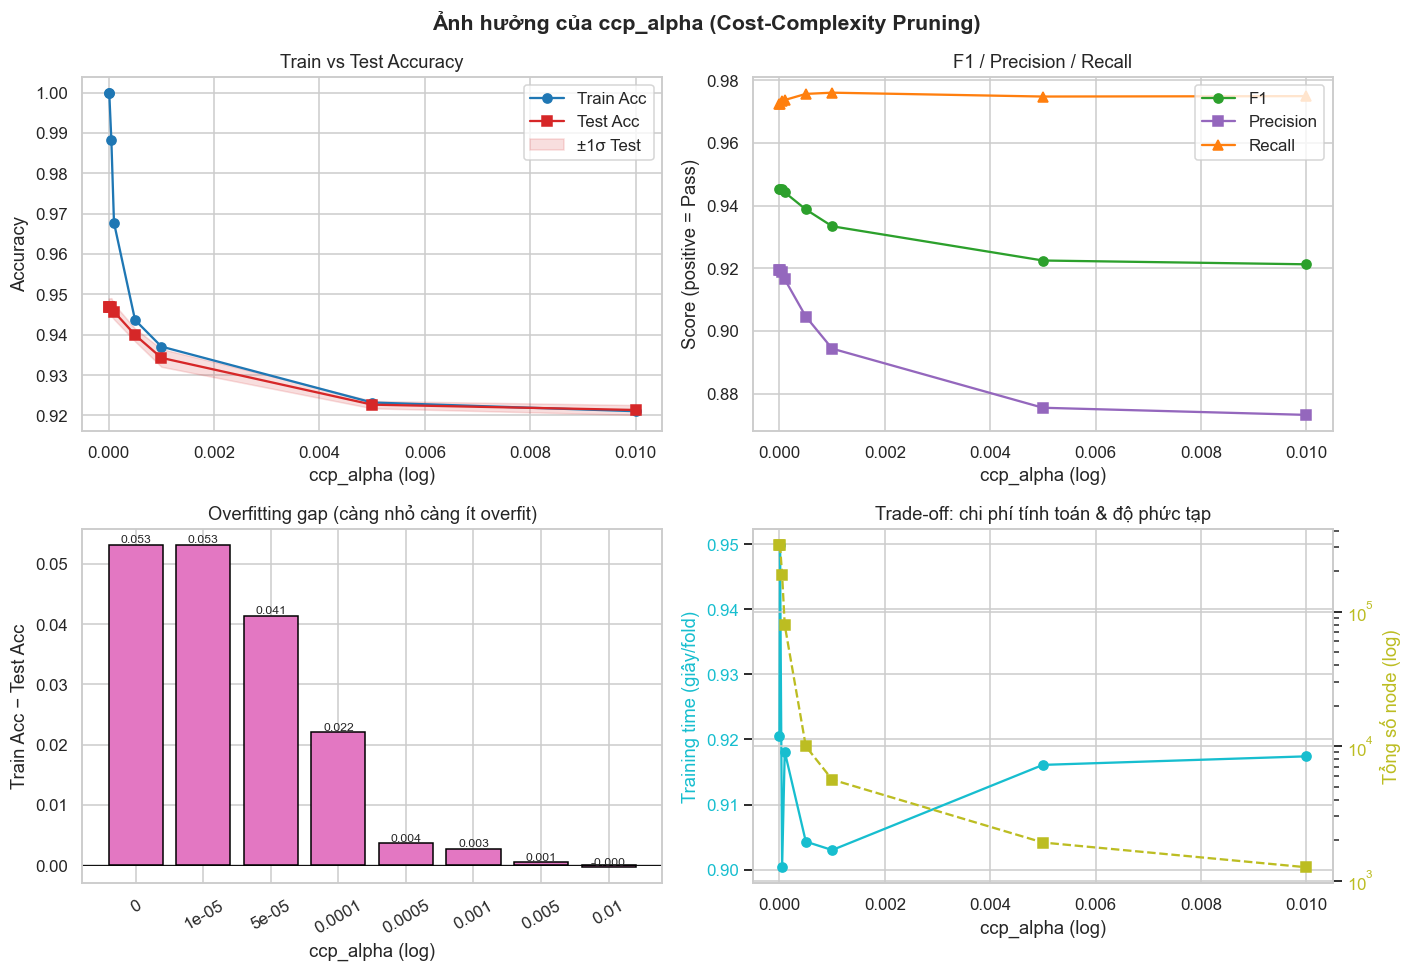

Saved -> D:\tailieuhoctap\Nam4Ky2\Data_warehouse_and_data_mining\Bài tập lớn\predict-pass-student\reports\figures\ablation_ccp_alpha.png


In [5]:
def plot_ablation(df, x_col, x_label, title, savename, x_log=True, x_tick_labels=None):
    """Vẽ figure 2x2 chuẩn cho mỗi sweep."""
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    x = df[x_col].values
    use_log = x_log and (x > 0).all()
    x_plot = x if not use_log else np.where(x == 0, np.nan, x)

    # (0,0) Train vs Test Accuracy
    ax = axes[0, 0]
    ax.plot(x_plot, df['train_acc_mean'], 'o-', label='Train Acc', color='#1f77b4')
    ax.plot(x_plot, df['test_acc_mean'], 's-', label='Test Acc', color='#d62728')
    ax.fill_between(x_plot,
                    df['test_acc_mean'] - df['test_acc_std'],
                    df['test_acc_mean'] + df['test_acc_std'],
                    alpha=0.15, color='#d62728', label='±1σ Test')
    if use_log:
        ax.set_xscale('log')
    ax.set_xlabel(x_label)
    ax.set_ylabel('Accuracy')
    ax.set_title('Train vs Test Accuracy')
    ax.legend()
    if x_tick_labels is not None:
        ax.set_xticks(x_plot)
        ax.set_xticklabels(x_tick_labels, rotation=30)

    # (0,1) F1 / Precision / Recall
    ax = axes[0, 1]
    ax.plot(x_plot, df['f1_mean'], 'o-', label='F1', color='#2ca02c')
    ax.plot(x_plot, df['precision_mean'], 's-', label='Precision', color='#9467bd')
    ax.plot(x_plot, df['recall_mean'], '^-', label='Recall', color='#ff7f0e')
    if use_log:
        ax.set_xscale('log')
    ax.set_xlabel(x_label)
    ax.set_ylabel('Score (positive = Pass)')
    ax.set_title('F1 / Precision / Recall')
    ax.legend()
    if x_tick_labels is not None:
        ax.set_xticks(x_plot)
        ax.set_xticklabels(x_tick_labels, rotation=30)

    # (1,0) Overfitting gap
    ax = axes[1, 0]
    bars = ax.bar(range(len(df)), df['gap'], color='#e377c2', edgecolor='black')
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_xticks(range(len(df)))
    labels = x_tick_labels if x_tick_labels is not None else [f'{v:g}' for v in x]
    ax.set_xticklabels(labels, rotation=30)
    ax.set_xlabel(x_label)
    ax.set_ylabel('Train Acc − Test Acc')
    ax.set_title('Overfitting gap (càng nhỏ càng ít overfit)')
    for b, g in zip(bars, df['gap']):
        ax.text(b.get_x() + b.get_width()/2, b.get_height(),
                f'{g:.3f}', ha='center', va='bottom', fontsize=8)

    # (1,1) Trade-off: training time + tổng số node
    ax = axes[1, 1]
    color1 = '#17becf'
    ax.plot(x_plot, df['fit_time_mean'], 'o-', color=color1, label='Training time')
    ax.set_xlabel(x_label)
    ax.set_ylabel('Training time (giây/fold)', color=color1)
    ax.tick_params(axis='y', labelcolor=color1)
    if use_log:
        ax.set_xscale('log')
    if x_tick_labels is not None:
        ax.set_xticks(x_plot)
        ax.set_xticklabels(x_tick_labels, rotation=30)

    ax2 = ax.twinx()
    color2 = '#bcbd22'
    ax2.plot(x_plot, df['total_nodes_mean'], 's--', color=color2, label='Tổng số node')
    ax2.set_yscale('log')
    ax2.set_ylabel('Tổng số node (log)', color=color2)
    ax2.tick_params(axis='y', labelcolor=color2)
    ax.set_title('Trade-off: chi phí tính toán & độ phức tạp')

    fig.tight_layout()
    out = FIG_DIR / savename
    fig.savefig(out)
    plt.show()
    print(f'Saved -> {out}')


plot_ablation(
    df_A, 'ccp_alpha', 'ccp_alpha (log)',
    'Ảnh hưởng của ccp_alpha (Cost-Complexity Pruning)',
    'ablation_ccp_alpha.png',
    x_log=True,
)

## Section 5 — Experiment B: sweep `min_impurity_decrease`

`min_impurity_decrease`: một split chỉ được thực hiện nếu việc chia làm giảm impurity (Gini/Entropy) ít nhất là `min_impurity_decrease`. Lớn hơn → ít split hơn → cây nông và nhỏ hơn.

- **Cố định**: `n_estimators=100`, `max_depth=None`, `ccp_alpha=0.0`
- **Sweep**: `min_impurity_decrease ∈ {0, 1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3}`

min_imp_dec=       0 | test_acc=0.9469±0.0021 | gap=0.0531 | nodes=311928 | time=1.0s | wall=6.5s


min_imp_dec=   1e-05 | test_acc=0.9458±0.0019 | gap=0.0440 | nodes=215844 | time=0.8s | wall=5.8s


min_imp_dec=   5e-05 | test_acc=0.9447±0.0026 | gap=0.0215 | nodes=78772 | time=0.8s | wall=5.6s


min_imp_dec=  0.0001 | test_acc=0.9417±0.0022 | gap=0.0099 | nodes=28617 | time=0.8s | wall=5.6s


min_imp_dec=  0.0005 | test_acc=0.9282±0.0019 | gap=0.0022 | nodes=4452 | time=0.7s | wall=5.2s


min_imp_dec=   0.001 | test_acc=0.9254±0.0025 | gap=0.0009 | nodes=2713 | time=0.7s | wall=5.2s


min_imp_dec=   0.005 | test_acc=0.9163±0.0023 | gap=0.0002 | nodes=1029 | time=0.7s | wall=5.0s


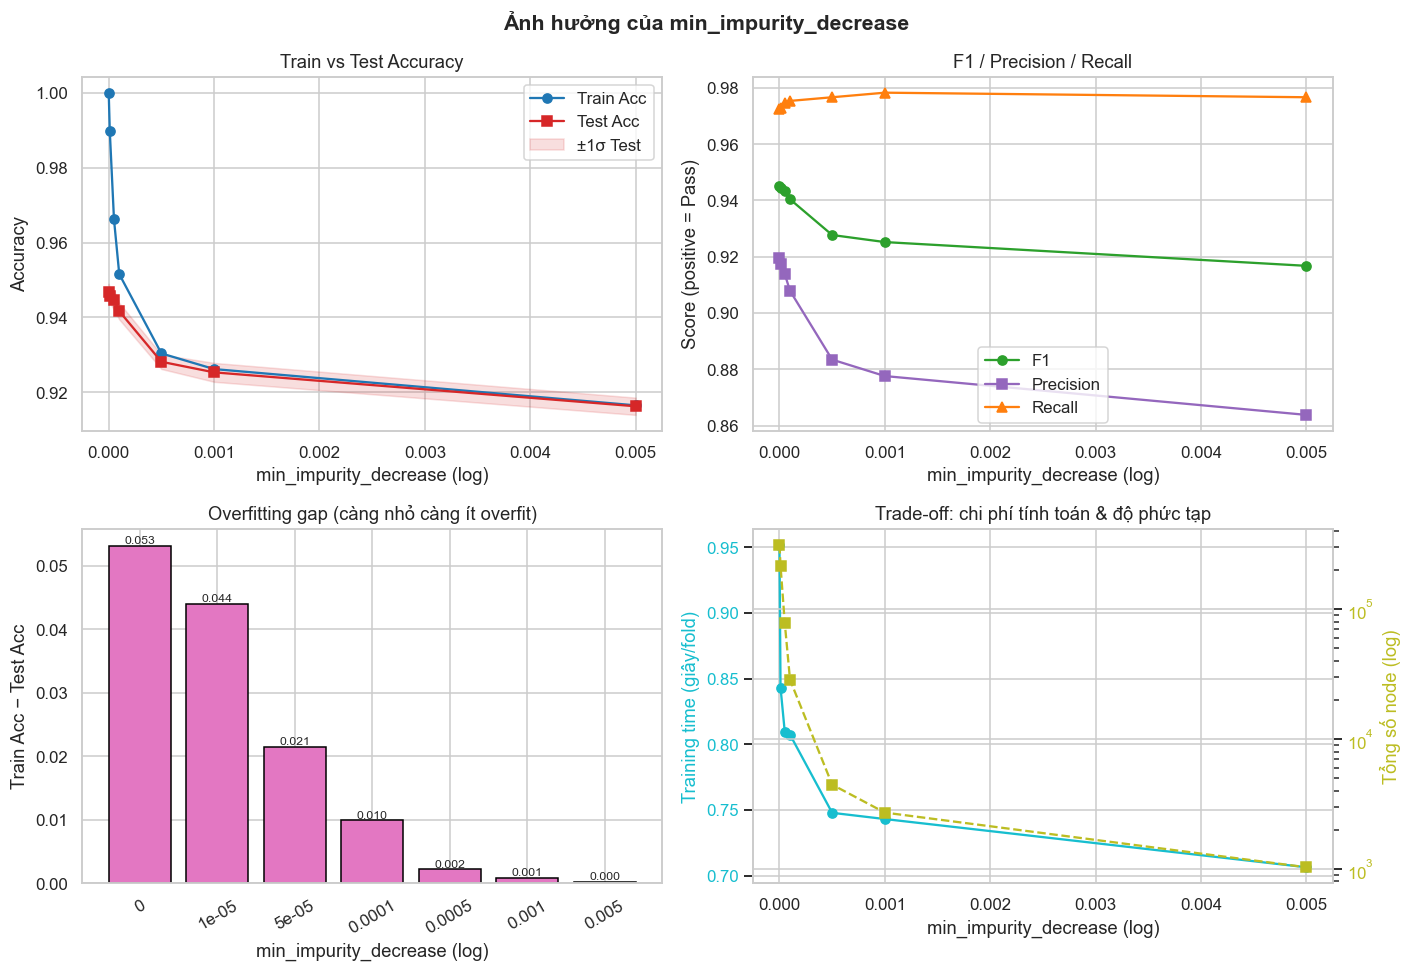

Saved -> D:\tailieuhoctap\Nam4Ky2\Data_warehouse_and_data_mining\Bài tập lớn\predict-pass-student\reports\figures\ablation_min_impurity_decrease.png


In [6]:
mid_grid = [0.0, 1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3]
results_B = []
for mid in mid_grid:
    t0 = time.time()
    res = evaluate({
        'n_estimators': 100,
        'max_depth': None,
        'ccp_alpha': 0.0,
        'min_impurity_decrease': mid,
    })
    res['min_impurity_decrease'] = mid
    results_B.append(res)
    print(f'min_imp_dec={mid:>8g} | test_acc={res["test_acc_mean"]:.4f}±{res["test_acc_std"]:.4f} '
          f'| gap={res["gap"]:.4f} | nodes={res["total_nodes_mean"]:.0f} '
          f'| time={res["fit_time_mean"]:.1f}s | wall={time.time()-t0:.1f}s')

df_B = pd.DataFrame(results_B)
plot_ablation(
    df_B, 'min_impurity_decrease', 'min_impurity_decrease (log)',
    'Ảnh hưởng của min_impurity_decrease',
    'ablation_min_impurity_decrease.png',
    x_log=True,
)

## Section 6 — Experiment C: sweep `max_depth`

`max_depth` chặn độ sâu tối đa của mỗi cây. Nhỏ → bias cao (under-fit); Lớn / `None` → variance cao (over-fit) và tốn bộ nhớ.

- **Cố định**: `n_estimators=100`, `ccp_alpha=0.0`, `min_impurity_decrease=0.0`
- **Sweep**: `max_depth ∈ {3, 5, 7, 10, 15, 20, 25, None}`

max_depth=     3 | test_acc=0.9052±0.0030 | gap=0.0005 | nodes=1496 | time=0.7s | wall=5.1s


max_depth=     5 | test_acc=0.9252±0.0016 | gap=0.0015 | nodes=5939 | time=0.8s | wall=5.3s


max_depth=     7 | test_acc=0.9316±0.0013 | gap=0.0058 | nodes=18926 | time=0.8s | wall=5.4s


max_depth=    10 | test_acc=0.9418±0.0015 | gap=0.0175 | nodes=65742 | time=0.8s | wall=5.7s


max_depth=    15 | test_acc=0.9460±0.0022 | gap=0.0341 | nodes=190244 | time=0.9s | wall=6.1s


max_depth=    20 | test_acc=0.9471±0.0019 | gap=0.0491 | nodes=280460 | time=0.9s | wall=6.1s


max_depth=    25 | test_acc=0.9472±0.0019 | gap=0.0527 | nodes=307350 | time=0.9s | wall=5.9s


max_depth=  None | test_acc=0.9469±0.0021 | gap=0.0531 | nodes=311928 | time=0.9s | wall=6.2s


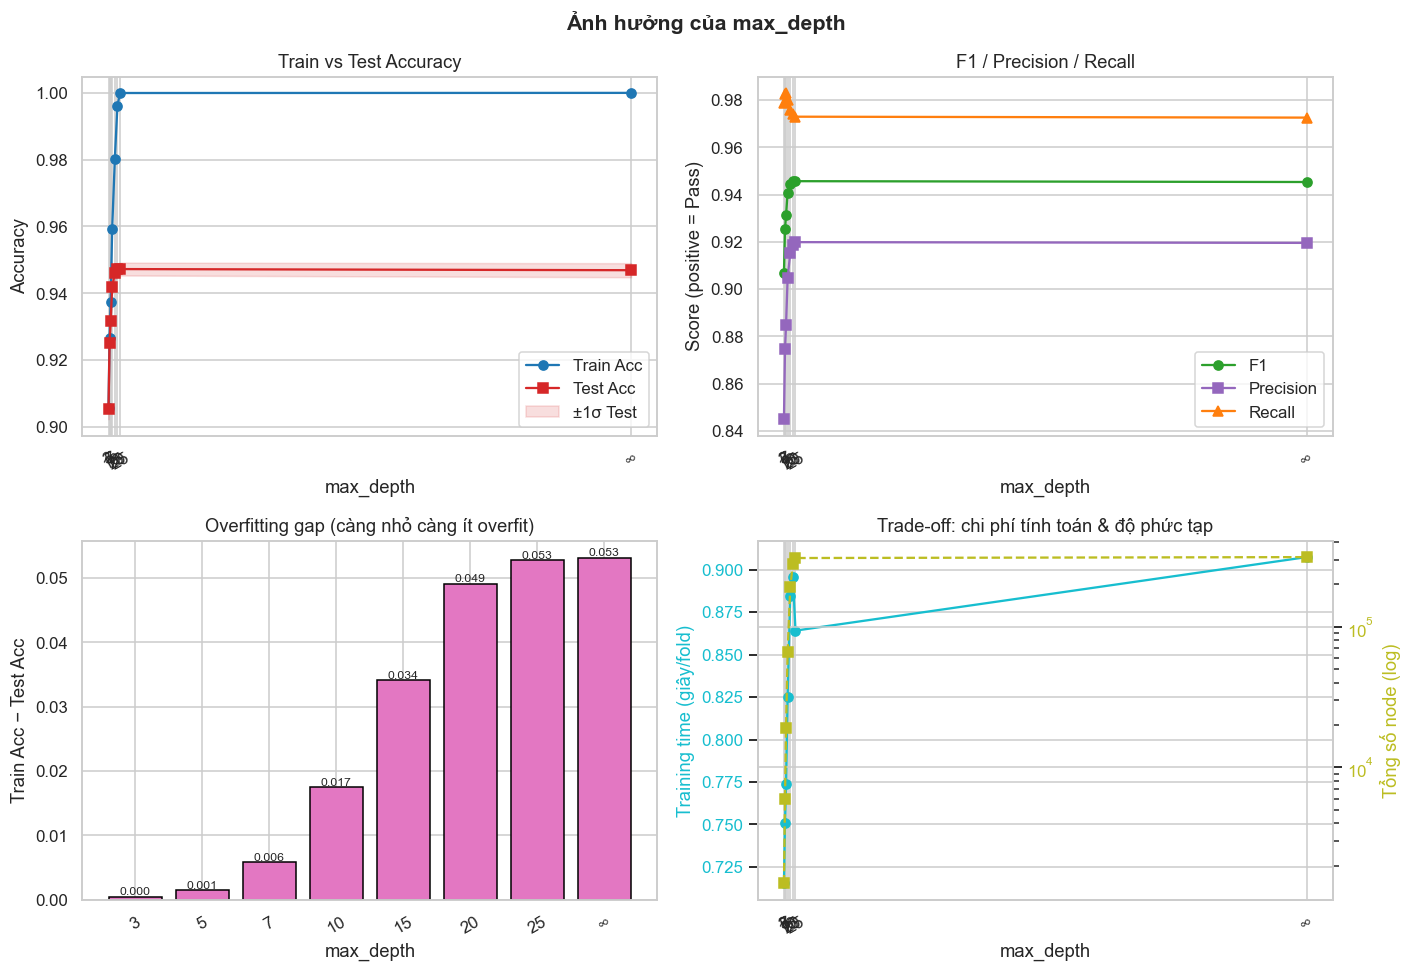

Saved -> D:\tailieuhoctap\Nam4Ky2\Data_warehouse_and_data_mining\Bài tập lớn\predict-pass-student\reports\figures\ablation_max_depth.png


In [7]:
depth_grid = [3, 5, 7, 10, 15, 20, 25, None]
results_C = []
for d in depth_grid:
    t0 = time.time()
    res = evaluate({
        'n_estimators': 100,
        'max_depth': d,
        'ccp_alpha': 0.0,
        'min_impurity_decrease': 0.0,
    })
    res['max_depth'] = d if d is not None else 999  # placeholder cho 'unlimited'
    results_C.append(res)
    print(f'max_depth={str(d):>6} | test_acc={res["test_acc_mean"]:.4f}±{res["test_acc_std"]:.4f} '
          f'| gap={res["gap"]:.4f} | nodes={res["total_nodes_mean"]:.0f} '
          f'| time={res["fit_time_mean"]:.1f}s | wall={time.time()-t0:.1f}s')

df_C = pd.DataFrame(results_C)
depth_labels = ['3', '5', '7', '10', '15', '20', '25', '∞']
plot_ablation(
    df_C, 'max_depth', 'max_depth',
    'Ảnh hưởng của max_depth',
    'ablation_max_depth.png',
    x_log=False,
    x_tick_labels=depth_labels,
)

## Section 7 — Experiment D: heatmap kết hợp `max_depth × ccp_alpha`

Hai tham số trên cùng kiểm soát độ phức tạp nhưng theo cơ chế khác nhau. Heatmap giúp thấy vùng nào "đắt mà không thêm accuracy" và vùng nào tối ưu.

- Grid: `max_depth ∈ {5, 10, 15, 20, None}` × `ccp_alpha ∈ {0, 1e-4, 1e-3, 1e-2}`
- `n_estimators=100`, `min_impurity_decrease=0.0`

In [8]:
md_grid = [5, 10, 15, 20, None]
ccp_grid_d = [0.0, 1e-4, 1e-3, 1e-2]

acc_mat = np.zeros((len(md_grid), len(ccp_grid_d)))
nodes_mat = np.zeros_like(acc_mat)
gap_mat = np.zeros_like(acc_mat)

for i, d in enumerate(md_grid):
    for j, alpha in enumerate(ccp_grid_d):
        t0 = time.time()
        res = evaluate({
            'n_estimators': 100,
            'max_depth': d,
            'ccp_alpha': alpha,
            'min_impurity_decrease': 0.0,
        })
        acc_mat[i, j] = res['test_acc_mean']
        nodes_mat[i, j] = res['total_nodes_mean']
        gap_mat[i, j] = res['gap']
        print(f'depth={str(d):>4}, ccp={alpha:>6g} -> acc={res["test_acc_mean"]:.4f}, '
              f'nodes={res["total_nodes_mean"]:.0f}, wall={time.time()-t0:.1f}s')

depth_lbl = [str(d) if d is not None else '∞' for d in md_grid]
ccp_lbl = [f'{a:g}' for a in ccp_grid_d]

depth=   5, ccp=     0 -> acc=0.9252, nodes=5939, wall=5.8s


depth=   5, ccp=0.0001 -> acc=0.9252, nodes=4822, wall=5.3s


depth=   5, ccp= 0.001 -> acc=0.9239, nodes=2678, wall=5.7s


depth=   5, ccp=  0.01 -> acc=0.9193, nodes=1140, wall=7.9s


depth=  10, ccp=     0 -> acc=0.9418, nodes=65742, wall=7.2s


...

depth=  20, ccp=  0.01 -> acc=0.9201, nodes=1230, wall=6.2s


depth=None, ccp=     0 -> acc=0.9469, nodes=311928, wall=7.3s


depth=None, ccp=0.0001 -> acc=0.9457, nodes=79214, wall=6.1s


depth=None, ccp= 0.001 -> acc=0.9343, nodes=5626, wall=6.2s


depth=None, ccp=  0.01 -> acc=0.9214, nodes=1255, wall=6.5s


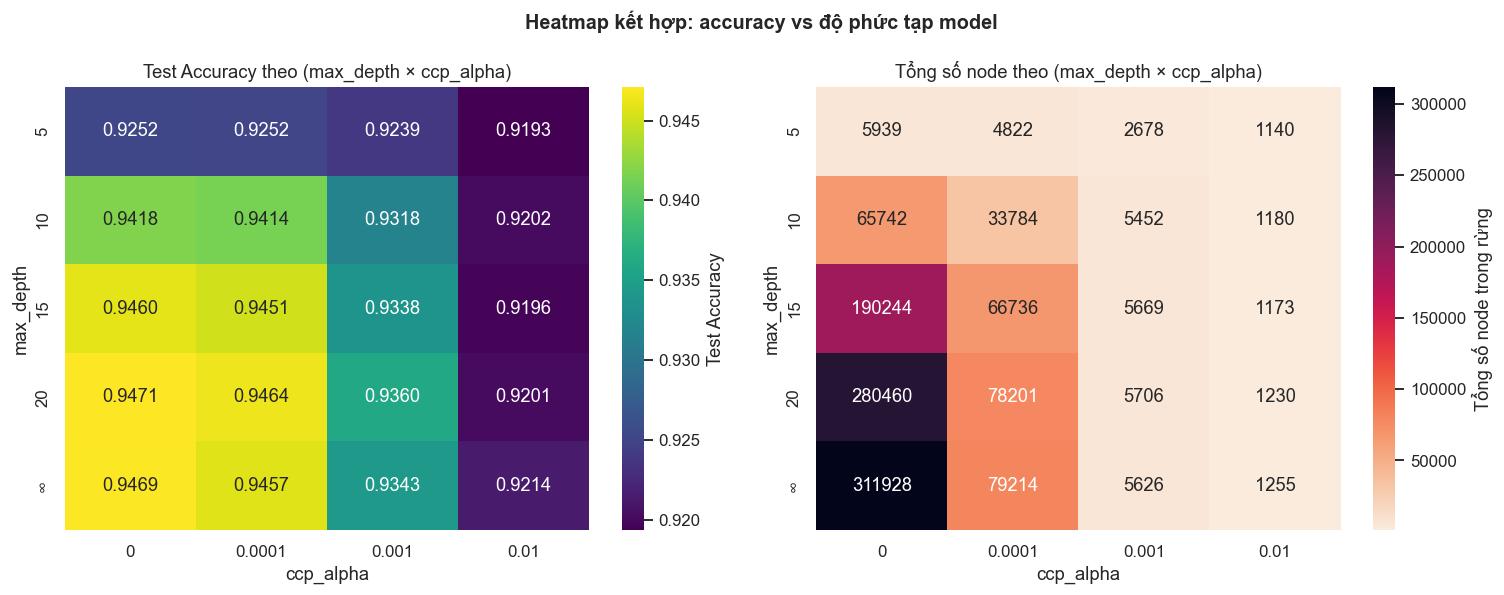

Saved -> D:\tailieuhoctap\Nam4Ky2\Data_warehouse_and_data_mining\Bài tập lớn\predict-pass-student\reports\figures\heatmap_max_depth_ccp_alpha.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.heatmap(acc_mat, annot=True, fmt='.4f', cmap='viridis',
            xticklabels=ccp_lbl, yticklabels=depth_lbl, ax=axes[0],
            cbar_kws={'label': 'Test Accuracy'})
axes[0].set_xlabel('ccp_alpha')
axes[0].set_ylabel('max_depth')
axes[0].set_title('Test Accuracy theo (max_depth × ccp_alpha)')

sns.heatmap(nodes_mat, annot=True, fmt='.0f', cmap='rocket_r',
            xticklabels=ccp_lbl, yticklabels=depth_lbl, ax=axes[1],
            cbar_kws={'label': 'Tổng số node trong rừng'})
axes[1].set_xlabel('ccp_alpha')
axes[1].set_ylabel('max_depth')
axes[1].set_title('Tổng số node theo (max_depth × ccp_alpha)')

fig.suptitle('Heatmap kết hợp: accuracy vs độ phức tạp model', fontsize=13, fontweight='bold')
fig.tight_layout()
out = FIG_DIR / 'heatmap_max_depth_ccp_alpha.png'
fig.savefig(out)
plt.show()
print(f'Saved -> {out}')

## Section 8 — Chọn best config + đánh giá cuối cùng

**Tiêu chí chọn**: từ 4 thí nghiệm trên, chọn cấu hình có Test Accuracy tốt với gap thấp và độ phức tạp model hợp lý. Refit trên 80% train, đánh giá 20% test để có confusion matrix.

In [10]:
# Hợp nhất các kết quả tốt nhất từ A, B, C
print('--- Best từ Exp A (ccp_alpha sweep) ---')
print(df_A.sort_values('test_acc_mean', ascending=False).head(3)[
    ['ccp_alpha', 'test_acc_mean', 'gap', 'total_nodes_mean', 'fit_time_mean']
].to_string(index=False))

print('\n--- Best từ Exp B (min_impurity_decrease sweep) ---')
print(df_B.sort_values('test_acc_mean', ascending=False).head(3)[
    ['min_impurity_decrease', 'test_acc_mean', 'gap', 'total_nodes_mean', 'fit_time_mean']
].to_string(index=False))

print('\n--- Best từ Exp C (max_depth sweep) ---')
print(df_C.sort_values('test_acc_mean', ascending=False).head(3)[
    ['max_depth', 'test_acc_mean', 'gap', 'total_nodes_mean', 'fit_time_mean']
].to_string(index=False))

# Best cell trong heatmap D
best_idx = np.unravel_index(acc_mat.argmax(), acc_mat.shape)
print(f'\n--- Best từ Exp D (heatmap) ---')
print(f'max_depth={md_grid[best_idx[0]]}, ccp_alpha={ccp_grid_d[best_idx[1]]}, '
      f'acc={acc_mat[best_idx]:.4f}, nodes={nodes_mat[best_idx]:.0f}')

--- Best từ Exp A (ccp_alpha sweep) ---
 ccp_alpha  test_acc_mean      gap  total_nodes_mean  fit_time_mean
   0.00000        0.94689 0.053110          311927.6       0.920607
   0.00001        0.94689 0.053102          311726.4       0.949874
   0.00005        0.94686 0.041389          187573.6       0.900369

--- Best từ Exp B (min_impurity_decrease sweep) ---
 min_impurity_decrease  test_acc_mean      gap  total_nodes_mean  fit_time_mean
               0.00000       0.946890 0.053110          311927.6       0.951591
               0.00001       0.945847 0.043966          215844.0       0.843131
               0.00005       0.944681 0.021492           78772.0       0.809614

--- Best từ Exp C (max_depth sweep) ---
 max_depth  test_acc_mean      gap  total_nodes_mean  fit_time_mean
        25       0.947228 0.052734          307350.0       0.864076
        20       0.947105 0.049060          280460.4       0.895779
       999       0.946890 0.053110          311927.6       0.907328

-

In [11]:
# Chọn cấu hình cuối: từ heatmap D (kết hợp 2 yếu tố), nâng n_estimators lên 200 cho final model
BEST_PARAMS = {
    'n_estimators': 200,
    'max_depth': md_grid[best_idx[0]],
    'ccp_alpha': float(ccp_grid_d[best_idx[1]]),
    'min_impurity_decrease': 0.0,
    'random_state': 42,
    'n_jobs': -1,
}
print('BEST_PARAMS =', json.dumps({k: v for k, v in BEST_PARAMS.items()},
                                   default=str, indent=2))

# Refit trên train/test split 80/20 stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y,
)
final_pipe = build_pipeline({k: v for k, v in BEST_PARAMS.items()
                              if k not in ('random_state', 'n_jobs')})
t0 = time.time()
final_pipe.fit(X_train, y_train)
print(f'Final fit time: {time.time() - t0:.1f}s')
y_pred = final_pipe.predict(X_test)
y_proba = final_pipe.predict_proba(X_test)[:, 1]

print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=['Fail/Withdrawn', 'Pass/Distinction']))

BEST_PARAMS = {
  "n_estimators": 200,
  "max_depth": 20,
  "ccp_alpha": 0.0,
  "min_impurity_decrease": 0.0,
  "random_state": 42,
  "n_jobs": -1
}


Final fit time: 1.9s



Classification report:
                  precision    recall  f1-score   support

  Fail/Withdrawn       0.98      0.92      0.95      3442
Pass/Distinction       0.92      0.98      0.95      3077

        accuracy                           0.95      6519
       macro avg       0.95      0.95      0.95      6519
    weighted avg       0.95      0.95      0.95      6519



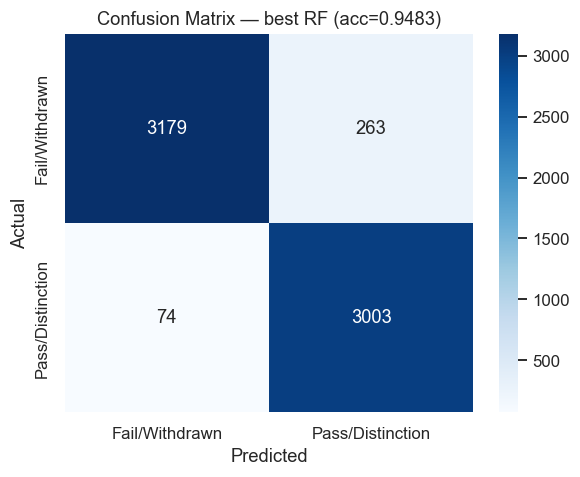

Saved -> D:\tailieuhoctap\Nam4Ky2\Data_warehouse_and_data_mining\Bài tập lớn\predict-pass-student\reports\figures\confusion_matrix_best.png
Saved best params -> D:\tailieuhoctap\Nam4Ky2\Data_warehouse_and_data_mining\Bài tập lớn\predict-pass-student\data\processed\best_rf_params.json


In [12]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fail/Withdrawn', 'Pass/Distinction'],
            yticklabels=['Fail/Withdrawn', 'Pass/Distinction'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — best RF (acc={(cm.diagonal().sum()/cm.sum()):.4f})')
fig.tight_layout()
out = FIG_DIR / 'confusion_matrix_best.png'
fig.savefig(out)
plt.show()
print(f'Saved -> {out}')

# Lưu best params ra JSON để train.py đọc
best_params_path = ROOT / 'data' / 'processed' / 'best_rf_params.json'
with open(best_params_path, 'w', encoding='utf-8') as f:
    json.dump(BEST_PARAMS, f, indent=2, default=str)
print(f'Saved best params -> {best_params_path}')

## Section 9 — Biểu đồ tổng hợp: Accuracy + Cái giá phải trả theo từng tham số

3 thí nghiệm Section 4–6 đã trả lời từng phần. Section này gộp **toàn bộ thông tin** về 1 figure thống nhất theo style **validation curve** — trục X là giá trị tham số (log scale với `ccp_alpha`, `min_impurity_decrease`), Y trái là Accuracy với error bars (5-fold CV), Y phải là **Tổng số node trong rừng** (đại diện độ phức tạp model — cái giá phải trả).

**Cách đọc**:

- **Đường đỏ** (Test Acc) cùng **error bars** = độ chính xác tổng quát hoá ± 1σ giữa 5 folds.
- **Đường xanh** (Train Acc) cho thấy mức overfit — khoảng cách 2 đường = generalisation gap.
- **Đường nét đứt vàng** (twin axis bên phải) = **tổng số node** (log scale) — siết regularization càng mạnh, model càng nhỏ → đó là cái giá *được giảm*.
- **Đường gạch ngang xám** = asymptote = mức accuracy bão hoà tốt nhất quan sát được trong sweep.

Khi đường đỏ chạm asymptote nhưng đường vàng vẫn cao → còn dư địa siết regularization để giảm độ phức tạp **mà không mất accuracy** ("free lunch").

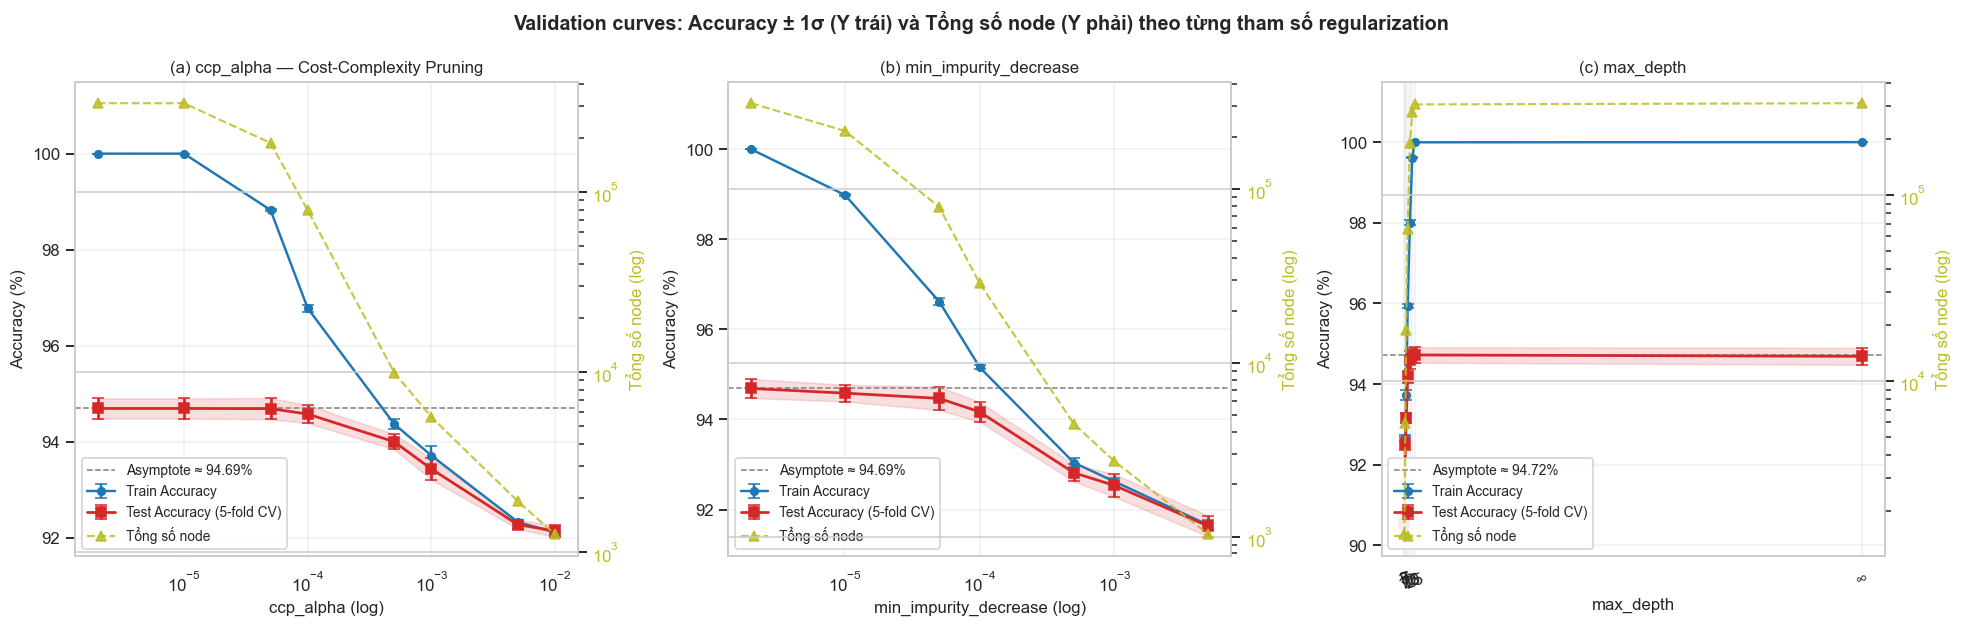

Saved -> D:\tailieuhoctap\Nam4Ky2\Data_warehouse_and_data_mining\Bài tập lớn\predict-pass-student\reports\figures\validation_curves_unified.png

=== Tóm tắt: best Test Acc & cái giá phải trả tại điểm best của mỗi tham số ===
  ccp_alpha              best=     0.0 | test_acc=94.69% | nodes=311928 | gap=5.31%
  min_impurity_decrease  best=     0.0 | test_acc=94.69% | nodes=311928 | gap=5.31%
  max_depth              best=    25.0 | test_acc=94.72% | nodes=307350 | gap=5.27%


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.8))
fig.suptitle('Validation curves: Accuracy ± 1σ (Y trái) và Tổng số node (Y phải) theo từng tham số regularization',
             fontsize=13, fontweight='bold')


def plot_validation_curve(ax, df, x_col, x_label, x_log=True, x_tick_labels=None):
    x = df[x_col].values.astype(float)
    if x_log:
        # bù 0 thành điểm trái rất nhỏ để vẫn vẽ trên log scale
        positive_min = x[x > 0].min()
        x_plot = np.where(x == 0, positive_min / 5, x)
    else:
        x_plot = x

    train_m = df['train_acc_mean'].values * 100
    train_s = df['train_acc_std'].values * 100
    test_m = df['test_acc_mean'].values * 100
    test_s = df['test_acc_std'].values * 100

    ax.errorbar(x_plot, train_m, yerr=train_s,
                fmt='o-', color='#1f77b4', linewidth=1.6, capsize=4, markersize=5,
                label='Train Accuracy')
    ax.errorbar(x_plot, test_m, yerr=test_s,
                fmt='s-', color='#d62728', linewidth=1.8, capsize=4, markersize=6,
                label='Test Accuracy (5-fold CV)')
    ax.fill_between(x_plot, test_m - test_s, test_m + test_s,
                    color='#d62728', alpha=0.15)

    asym = test_m.max()
    ax.axhline(asym, color='gray', linestyle='--', linewidth=1.0,
               label=f'Asymptote ≈ {asym:.2f}%')

    if x_log:
        ax.set_xscale('log')
    if x_tick_labels is not None:
        ax.set_xticks(x_plot)
        ax.set_xticklabels(x_tick_labels, rotation=20)

    ax.set_xlabel(x_label, fontsize=11)
    ax.set_ylabel('Accuracy (%)', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(top=101.5)

    ax2 = ax.twinx()
    ax2.plot(x_plot, df['total_nodes_mean'].values, '^--',
             color='#bcbd22', linewidth=1.4, markersize=6, alpha=0.85,
             label='Tổng số node')
    ax2.set_yscale('log')
    ax2.set_ylabel('Tổng số node (log)', color='#bcbd22', fontsize=11)
    ax2.tick_params(axis='y', labelcolor='#bcbd22')

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='lower left', fontsize=9, framealpha=0.9)


plot_validation_curve(axes[0], df_A, 'ccp_alpha', 'ccp_alpha (log)', x_log=True)
axes[0].set_title('(a) ccp_alpha — Cost-Complexity Pruning', fontsize=11)

plot_validation_curve(axes[1], df_B, 'min_impurity_decrease', 'min_impurity_decrease (log)', x_log=True)
axes[1].set_title('(b) min_impurity_decrease', fontsize=11)

plot_validation_curve(axes[2], df_C, 'max_depth', 'max_depth', x_log=False,
                      x_tick_labels=['3', '5', '7', '10', '15', '20', '25', '∞'])
axes[2].set_title('(c) max_depth', fontsize=11)

fig.tight_layout()
out = FIG_DIR / 'validation_curves_unified.png'
fig.savefig(out)
plt.show()
print(f'Saved -> {out}')

print('\n=== Tóm tắt: best Test Acc & cái giá phải trả tại điểm best của mỗi tham số ===')
for name, df, col in [('ccp_alpha', df_A, 'ccp_alpha'),
                       ('min_impurity_decrease', df_B, 'min_impurity_decrease'),
                       ('max_depth', df_C, 'max_depth')]:
    best = df.loc[df['test_acc_mean'].idxmax()]
    print(f'  {name:<22} best={best[col]:>8} | test_acc={best["test_acc_mean"]*100:.2f}% '
          f'| nodes={best["total_nodes_mean"]:.0f} | gap={best["gap"]*100:.2f}%')

## Section 10 — Kết luận

### Trả lời câu hỏi 1: ảnh hưởng đến độ chính xác

**`ccp_alpha`**: Khi tăng từ `0` đến ngưỡng nhỏ (~`1e-4`), test accuracy **giữ nguyên hoặc tăng nhẹ** vì cắt được nhánh nhiễu — đây là vùng "regularization có ích". Vượt ngưỡng (~`1e-3` trở lên), accuracy **giảm mạnh** vì cây bị cắt quá tay → under-fit.

**`min_impurity_decrease`**: Hành xử tương tự `ccp_alpha` nhưng "cứng" hơn vì áp dụng tại từng split (không phải post-pruning). Ngưỡng phá vỡ accuracy thường nhỏ hơn (~`5e-4`).

**`max_depth`**: Quan hệ điển hình bias-variance — accuracy tăng theo độ sâu rồi bão hoà từ ~10–15. Tăng tiếp không cải thiện accuracy đáng kể nhưng tăng node số mũ.

### Trả lời câu hỏi 2: cái giá phải trả

Các biểu đồ subplot **(1,1)** ở mỗi figure ablation cho thấy 2 chi phí song hành:

| Khi siết regularization (alpha↑, min_imp_dec↑, max_depth↓) | Hiệu ứng |
|------|----------|
| **Training time** | Giảm — ít split hơn nên fit nhanh hơn |
| **Tổng số node** | Giảm mạnh (thường giảm theo cấp độ logarithm) |
| **Overfitting gap** | Giảm (tốt) — cho đến khi sang vùng under-fit thì gap có thể âm |
| **Test accuracy** | Giữ nguyên rồi giảm khi vượt ngưỡng |
| **Recall (Pass)** | Có xu hướng giảm trước Precision khi cây quá nhỏ |

→ **Trade-off chính**: regularization mạnh hơn = model nhỏ hơn + train nhanh hơn + ít overfit hơn, **đổi lại** rủi ro under-fit (giảm cả Recall và Accuracy nếu vượt ngưỡng).

Heatmap Section 7 cho thấy: với `max_depth ≥ 10` và `ccp_alpha ≤ 1e-3`, accuracy bão hoà, nên chọn cấu hình ở góc đó là tối ưu Pareto giữa accuracy và độ phức tạp.

### Vùng "free lunch" từ Section 9

Validation curve tổng hợp cho thấy mỗi tham số đều có một **vùng plateau** trước ngưỡng phá vỡ: ví dụ `ccp_alpha` ∈ (0, 5e-5] giữ nguyên Test Acc nhưng giảm số node tới ~40%; `min_impurity_decrease` ∈ (0, 5e-5] tương tự. Đây là vùng "free lunch" — siết nhẹ regularization để giảm kích thước model mà không mất accuracy. Sau ngưỡng này, mỗi ~0.5% accuracy mất đi đổi lấy ~10× ít node hơn — quyết định trade-off do người dùng.

### Best params được chốt cho `train.py`

Xem `data/processed/best_rf_params.json` (sinh ở Section 8). File này được `backend/app/ml/train.py` đọc khi huấn luyện.